# Yol Risk Analizi — Makine Öğrenimi Projesi
**Veri:** US Accidents (2016–2023) | **Hedef:** Düşük / Orta / Yüksek Risk Sınıflandırması

## HÜCRE 1 — Kütüphaneler

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import optuna
import time
import gc
import shap
import joblib

from lightgbm import LGBMClassifier
from lazypredict.Supervised import LazyClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.dummy import DummyClassifier
from sklearn.utils import resample
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, ConfusionMatrixDisplay, fbeta_score,
    roc_curve, auc, precision_recall_curve, average_precision_score

)

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option('display.max_columns', None)
print('Kütüphaneler yüklendi ✓')

Kütüphaneler yüklendi ✓


## HÜCRE 2 — Veri Yükleme

In [2]:
cols = [
    'Severity', 'Start_Time', 'Start_Lat', 'Start_Lng',
    'Temperature(F)', 'Humidity(%)', 'Pressure(in)',
    'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)',
    'Weather_Condition', 'Crossing', 'Junction', 'Stop',
    'Traffic_Signal', 'Amenity', 'Bump', 'Give_Way',
    'No_Exit', 'Railway', 'Roundabout', 'Station',
    'Traffic_Calming', 'Sunrise_Sunset', 'Street'
]

df = pd.read_csv('../data/us_accident.csv', usecols=cols)
print(f'Toplam satır: {len(df):,}')
print(f'\nSeverity dağılımı:\n{df["Severity"].value_counts()}')
df.head()

Toplam satır: 7,728,394

Severity dağılımı:
Severity
2    6156981
3    1299337
4     204710
1      67366
Name: count, dtype: int64


,Severity,Start_Time,Start_Lat,Start_Lng,Street,Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Sunrise_Sunset
0,3,2016-02-08 05:46:00,39.87,-84.06,I-70 E,36.90,91.00,29.68,10.00,NaN,0.02,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,Night
1,2,2016-02-08 06:07:59,39.93,-82.83,Brice Rd,37.90,100.00,29.65,10.00,NaN,0.00,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,Night
2,2,2016-02-08 06:49:27,39.06,-84.03,State Route 32,36.00,100.00,29.67,10.00,3.50,NaN,Overcast,False,False,False,False,False,False,False,False,False,False,False,True,Night
3,3,2016-02-08 07:23:34,39.75,-84.21,I-75 S,35.10,96.00,29.64,9.00,4.60,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,Night
4,2,2016-02-08 07:39:07,39.63,-84.19,Miamisburg Centerville Rd,36.00,89.00,29.65,6.00,3.50,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,True,Day


## HÜCRE 3 — EDA: Eksik Veri

In [3]:
print('Eksik veri (%):')
missing = df.isnull().sum() / len(df) * 100
print(missing[missing > 0].sort_values(ascending=False).round(2))

Eksik veri (%):
Precipitation(in)   28.51
Wind_Speed(mph)      7.39
Visibility(mi)       2.29
Humidity(%)          2.25
Weather_Condition    2.24
Temperature(F)       2.12
Pressure(in)         1.82
Sunrise_Sunset       0.30
Street               0.14
dtype: float64


## HÜCRE 4 — EDA: Severity Dağılımı

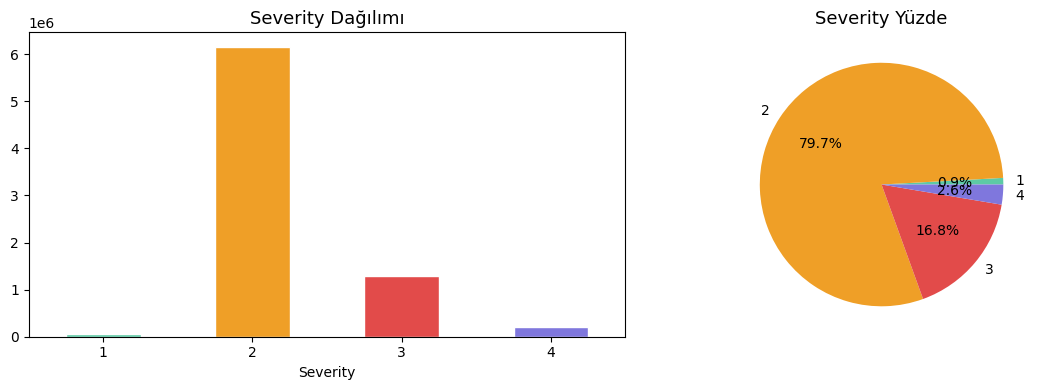

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['Severity'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0],
    color=['#5DCAA5','#EF9F27','#E24B4A','#7F77DD'], edgecolor='white'
)
axes[0].set_title('Severity Dağılımı', fontsize=13)
axes[0].tick_params(axis='x', rotation=0)
df['Severity'].value_counts(normalize=True).sort_index().plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%',
    colors=['#5DCAA5','#EF9F27','#E24B4A','#7F77DD']
)
axes[1].set_title('Severity Yüzde', fontsize=13)
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

## HÜCRE 5 — EDA: Saatlik Kaza Dağılımı

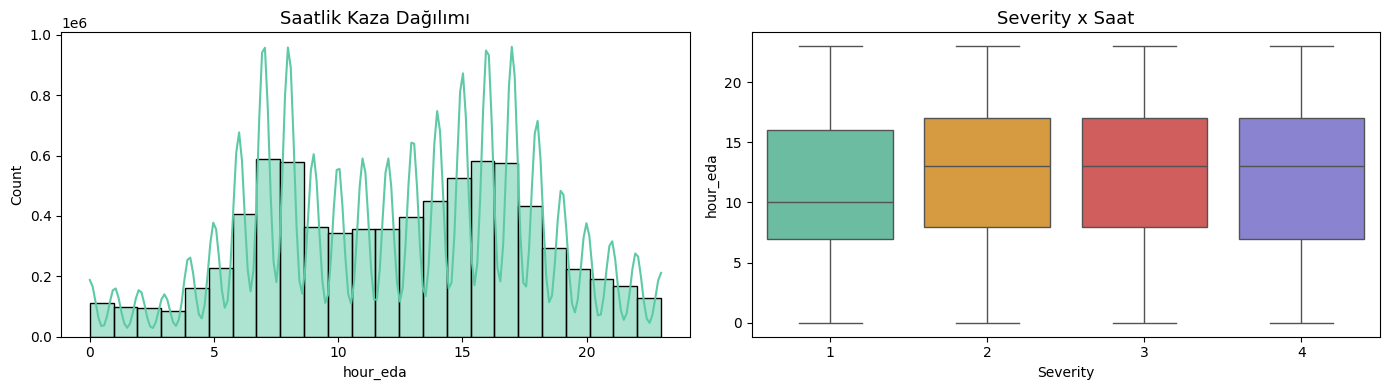

In [5]:
df['Start_Time'] = pd.to_datetime(df['Start_Time'], format='mixed')
df['hour_eda'] = df['Start_Time'].dt.hour

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df['hour_eda'], bins=24, ax=axes[0], color='#5DCAA5', kde=True)
axes[0].set_title('Saatlik Kaza Dağılımı', fontsize=13)
sns.boxplot(x='Severity', y='hour_eda', data=df, ax=axes[1],
            palette=['#5DCAA5','#EF9F27','#E24B4A','#7F77DD'])
axes[1].set_title('Severity x Saat', fontsize=13)
plt.tight_layout()
plt.show()

## HÜCRE 6 — EDA: Hava Durumu

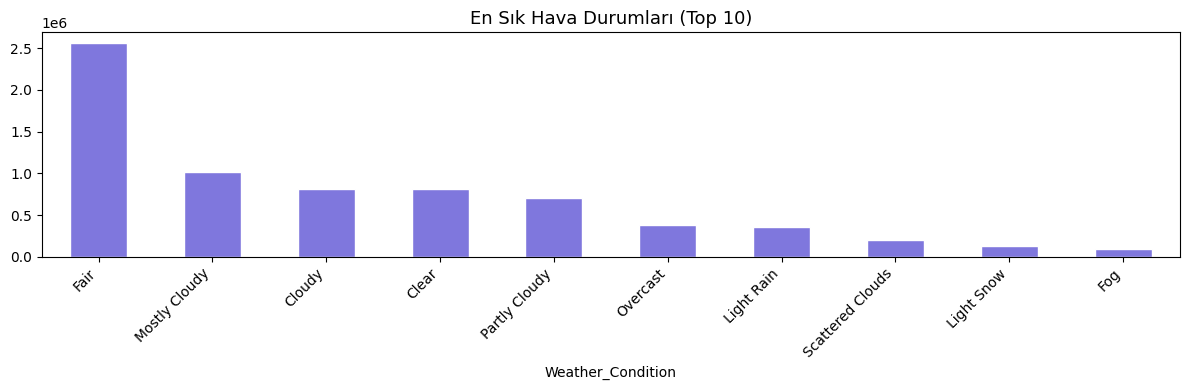

In [6]:
top_weather = df['Weather_Condition'].value_counts().head(10)
plt.figure(figsize=(12, 4))
top_weather.plot(kind='bar', color='#7F77DD', edgecolor='white')
plt.title('En Sık Hava Durumları (Top 10)', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## HÜCRE 7 — Etiket Oluşturma (Risk_Level)

In [7]:
# Severity 1+2 → Düşük (0) | Severity 3 → Orta (1) | Severity 4 → Yüksek (2)
df['Risk_Level'] = df['Severity'].map({1: 0, 2: 0, 3: 1, 4: 2})
print('Risk_Level dağılımı:')
print(df['Risk_Level'].value_counts())
print('\nYüzde:')
print(df['Risk_Level'].value_counts(normalize=True).round(3))

Risk_Level dağılımı:
Risk_Level
0    6224347
1    1299337
2     204710
Name: count, dtype: int64

Yüzde:
Risk_Level
0   0.81
1   0.17
2   0.03
Name: proportion, dtype: float64


## HÜCRE 8 — Feature Engineering: Zaman

In [8]:
df['hour']        = df['Start_Time'].dt.hour
df['month']       = df['Start_Time'].dt.month
df['day_of_week'] = df['Start_Time'].dt.dayofweek
df['is_weekend']  = df['day_of_week'].isin([5, 6]).astype(int)
df['is_rush_hour']= df['hour'].isin([7,8,9,16,17,18]).astype(int)
df['is_night']    = (df['Sunrise_Sunset'] == 'Night').astype(int)
print('Zaman featureları oluşturuldu ✓')

Zaman featureları oluşturuldu ✓


## HÜCRE 9 — Feature Engineering: Hava (Sayısal)

In [9]:
df['Temperature(F)']    = df['Temperature(F)'].fillna(df['Temperature(F)'].median())
df['Humidity(%)']       = df['Humidity(%)'].fillna(df['Humidity(%)'].median())
df['Pressure(in)']      = df['Pressure(in)'].fillna(df['Pressure(in)'].median())
df['Visibility(mi)']    = df['Visibility(mi)'].fillna(df['Visibility(mi)'].median())
df['Wind_Speed(mph)']   = df['Wind_Speed(mph)'].fillna(df['Wind_Speed(mph)'].median())
df['Precipitation(in)'] = df['Precipitation(in)'].fillna(0.0)
df['low_visibility']    = (df['Visibility(mi)'] < 5).astype(int)
df['extreme_temp']      = ((df['Temperature(F)'] < 32) | (df['Temperature(F)'] > 95)).astype(int)
print('Sayısal hava featureları oluşturuldu ✓')

Sayısal hava featureları oluşturuldu ✓


## HÜCRE 10 — Feature Engineering: Hava (Kategorik)

In [10]:
def group_weather(condition):
    if pd.isna(condition): return 'Clear'
    condition = str(condition).lower()
    if any(w in condition for w in ['rain','drizzle','shower']): return 'Rain'
    elif any(w in condition for w in ['snow','sleet','ice','hail','wintry']): return 'Snow'
    elif any(w in condition for w in ['fog','mist','smoke','haze']): return 'Fog'
    elif any(w in condition for w in ['cloud','overcast']): return 'Cloudy'
    else: return 'Clear'

df['Weather_Group'] = df['Weather_Condition'].apply(group_weather)
df['bad_weather']   = df['Weather_Group'].isin(['Rain','Snow','Fog']).astype(int)
print('Hava grubu dağılımı:')
print(df['Weather_Group'].value_counts())

Hava grubu dağılımı:
Weather_Group
Clear     3648003
Cloudy    3163750
Rain       540467
Fog        202399
Snow       173775
Name: count, dtype: int64


## HÜCRE 11 — Feature Engineering: Yol & POI

In [11]:
poi_cols = ['Crossing','Junction','Stop','Traffic_Signal',
            'Amenity','Bump','Give_Way','No_Exit',
            'Railway','Roundabout','Station','Traffic_Calming']
for col in poi_cols:
    if col in df.columns:
        df[col] = df[col].astype(int)

df['complex_road'] = df[['Crossing','Junction','Stop','Traffic_Signal']].sum(axis=1)
print('POI featureları oluşturuldu ✓')

POI featureları oluşturuldu ✓


## HÜCRE 12 — Feature Engineering: Interaction

In [12]:
df['night_bad_weather'] = df['is_night'] * df['bad_weather']
df['rush_complex_road'] = df['is_rush_hour'] * (df['complex_road'] > 0).astype(int)
df['night_low_vis']     = df['is_night'] * df['low_visibility']
print('Interaction featureları oluşturuldu ✓')

Interaction featureları oluşturuldu ✓


## HÜCRE 13 — Feature Engineering: Yeni Featurelar (is_highway, season, risk_score)

In [13]:
# is_highway — Street kolonundan otoyol tespiti
df['is_highway'] = df['Street'].str.contains(
    'I-|Highway|Hwy|Freeway|Fwy', case=False, na=False
).astype(int)

# season — ay'dan mevsim
df['season'] = df['month'].map({
    12:0, 1:0, 2:0,
    3:1,  4:1, 5:1,
    6:2,  7:2, 8:2,
    9:3, 10:3, 11:3
})

# risk_score — additive
df['risk_score'] = (
    df['bad_weather'] +
    df['is_night'] +
    df['low_visibility'] +
    df['extreme_temp'] +
    (df['complex_road'] > 0).astype(int) +
    df['is_highway']
)

print(f'Otoyol kazası oranı : {df["is_highway"].mean():.2%}')
print(f'Season dağılımı:\n{df["season"].value_counts().sort_index()}')
print(f'Risk score dağılımı:\n{df["risk_score"].value_counts().sort_index()}')

Otoyol kazası oranı : 36.62%
Season dağılımı:
season
0    2258273
1    1700071
2    1683374
3    2086676
Name: count, dtype: int64
Risk score dağılımı:
risk_score
0    1857235
1    3297571
2    1762203
3     585463
4     176599
5      46080
6       3243
Name: count, dtype: int64


## HÜCRE 14 — df_model Oluştur & Gereksiz Kolonları Sil

In [14]:
drop_cols = ['Severity','Start_Time','Weather_Condition',
             'Sunrise_Sunset','hour_eda','Street']
df = df.drop(columns=drop_cols, errors='ignore')

coords   = df[['Start_Lat','Start_Lng']].copy()
df_model = df.drop(columns=['Start_Lat','Start_Lng'], errors='ignore')

print(f'df_model shape: {df_model.shape}')
print(f'Kolonlar: {list(df_model.columns)}')

df_model shape: (7728394, 36)
Kolonlar: ['Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Risk_Level', 'hour', 'month', 'day_of_week', 'is_weekend', 'is_rush_hour', 'is_night', 'low_visibility', 'extreme_temp', 'Weather_Group', 'bad_weather', 'complex_road', 'night_bad_weather', 'rush_complex_road', 'night_low_vis', 'is_highway', 'season', 'risk_score']


## HÜCRE 15 — Encoding

In [15]:
if 'Weather_Group' in df_model.columns:
    le = LabelEncoder()
    df_model['Weather_Group'] = le.fit_transform(df_model['Weather_Group'].astype(str))
    print(f'Weather_Group encode edildi ✓ — {dict(enumerate(le.classes_))}')

remaining = df_model.select_dtypes(include='object').columns.tolist()
if remaining:
    df_model = df_model.drop(columns=remaining)
    print(f'Drop: {remaining}')

bool_cols = df_model.select_dtypes(include='bool').columns.tolist()
if bool_cols:
    df_model[bool_cols] = df_model[bool_cols].astype(int)

for col in df_model.columns:
    if col == 'Risk_Level':
        continue
    if df_model[col].dtype == 'int64':
        df_model[col] = df_model[col].astype('int32')
    elif df_model[col].dtype == 'float64':
        df_model[col] = df_model[col].astype('float32')

print(f'Bellek: {df_model.memory_usage(deep=True).sum()/1024**2:.1f} MB')
print('Tip dönüşümü tamamlandı ✓')

print(f'Bellek: {df_model.memory_usage(deep=True).sum()/1024**2:.1f} MB')
print(f'Object kolon: {df_model.select_dtypes(include="object").shape[1]} — Temiz ✓')

Weather_Group encode edildi ✓ — {0: 'Clear', 1: 'Cloudy', 2: 'Fog', 3: 'Rain', 4: 'Snow'}
Bellek: 1090.8 MB
Tip dönüşümü tamamlandı ✓
Bellek: 1090.8 MB
Object kolon: 0 — Temiz ✓


## Hücre — 15.5 Korelasyon Matrisi

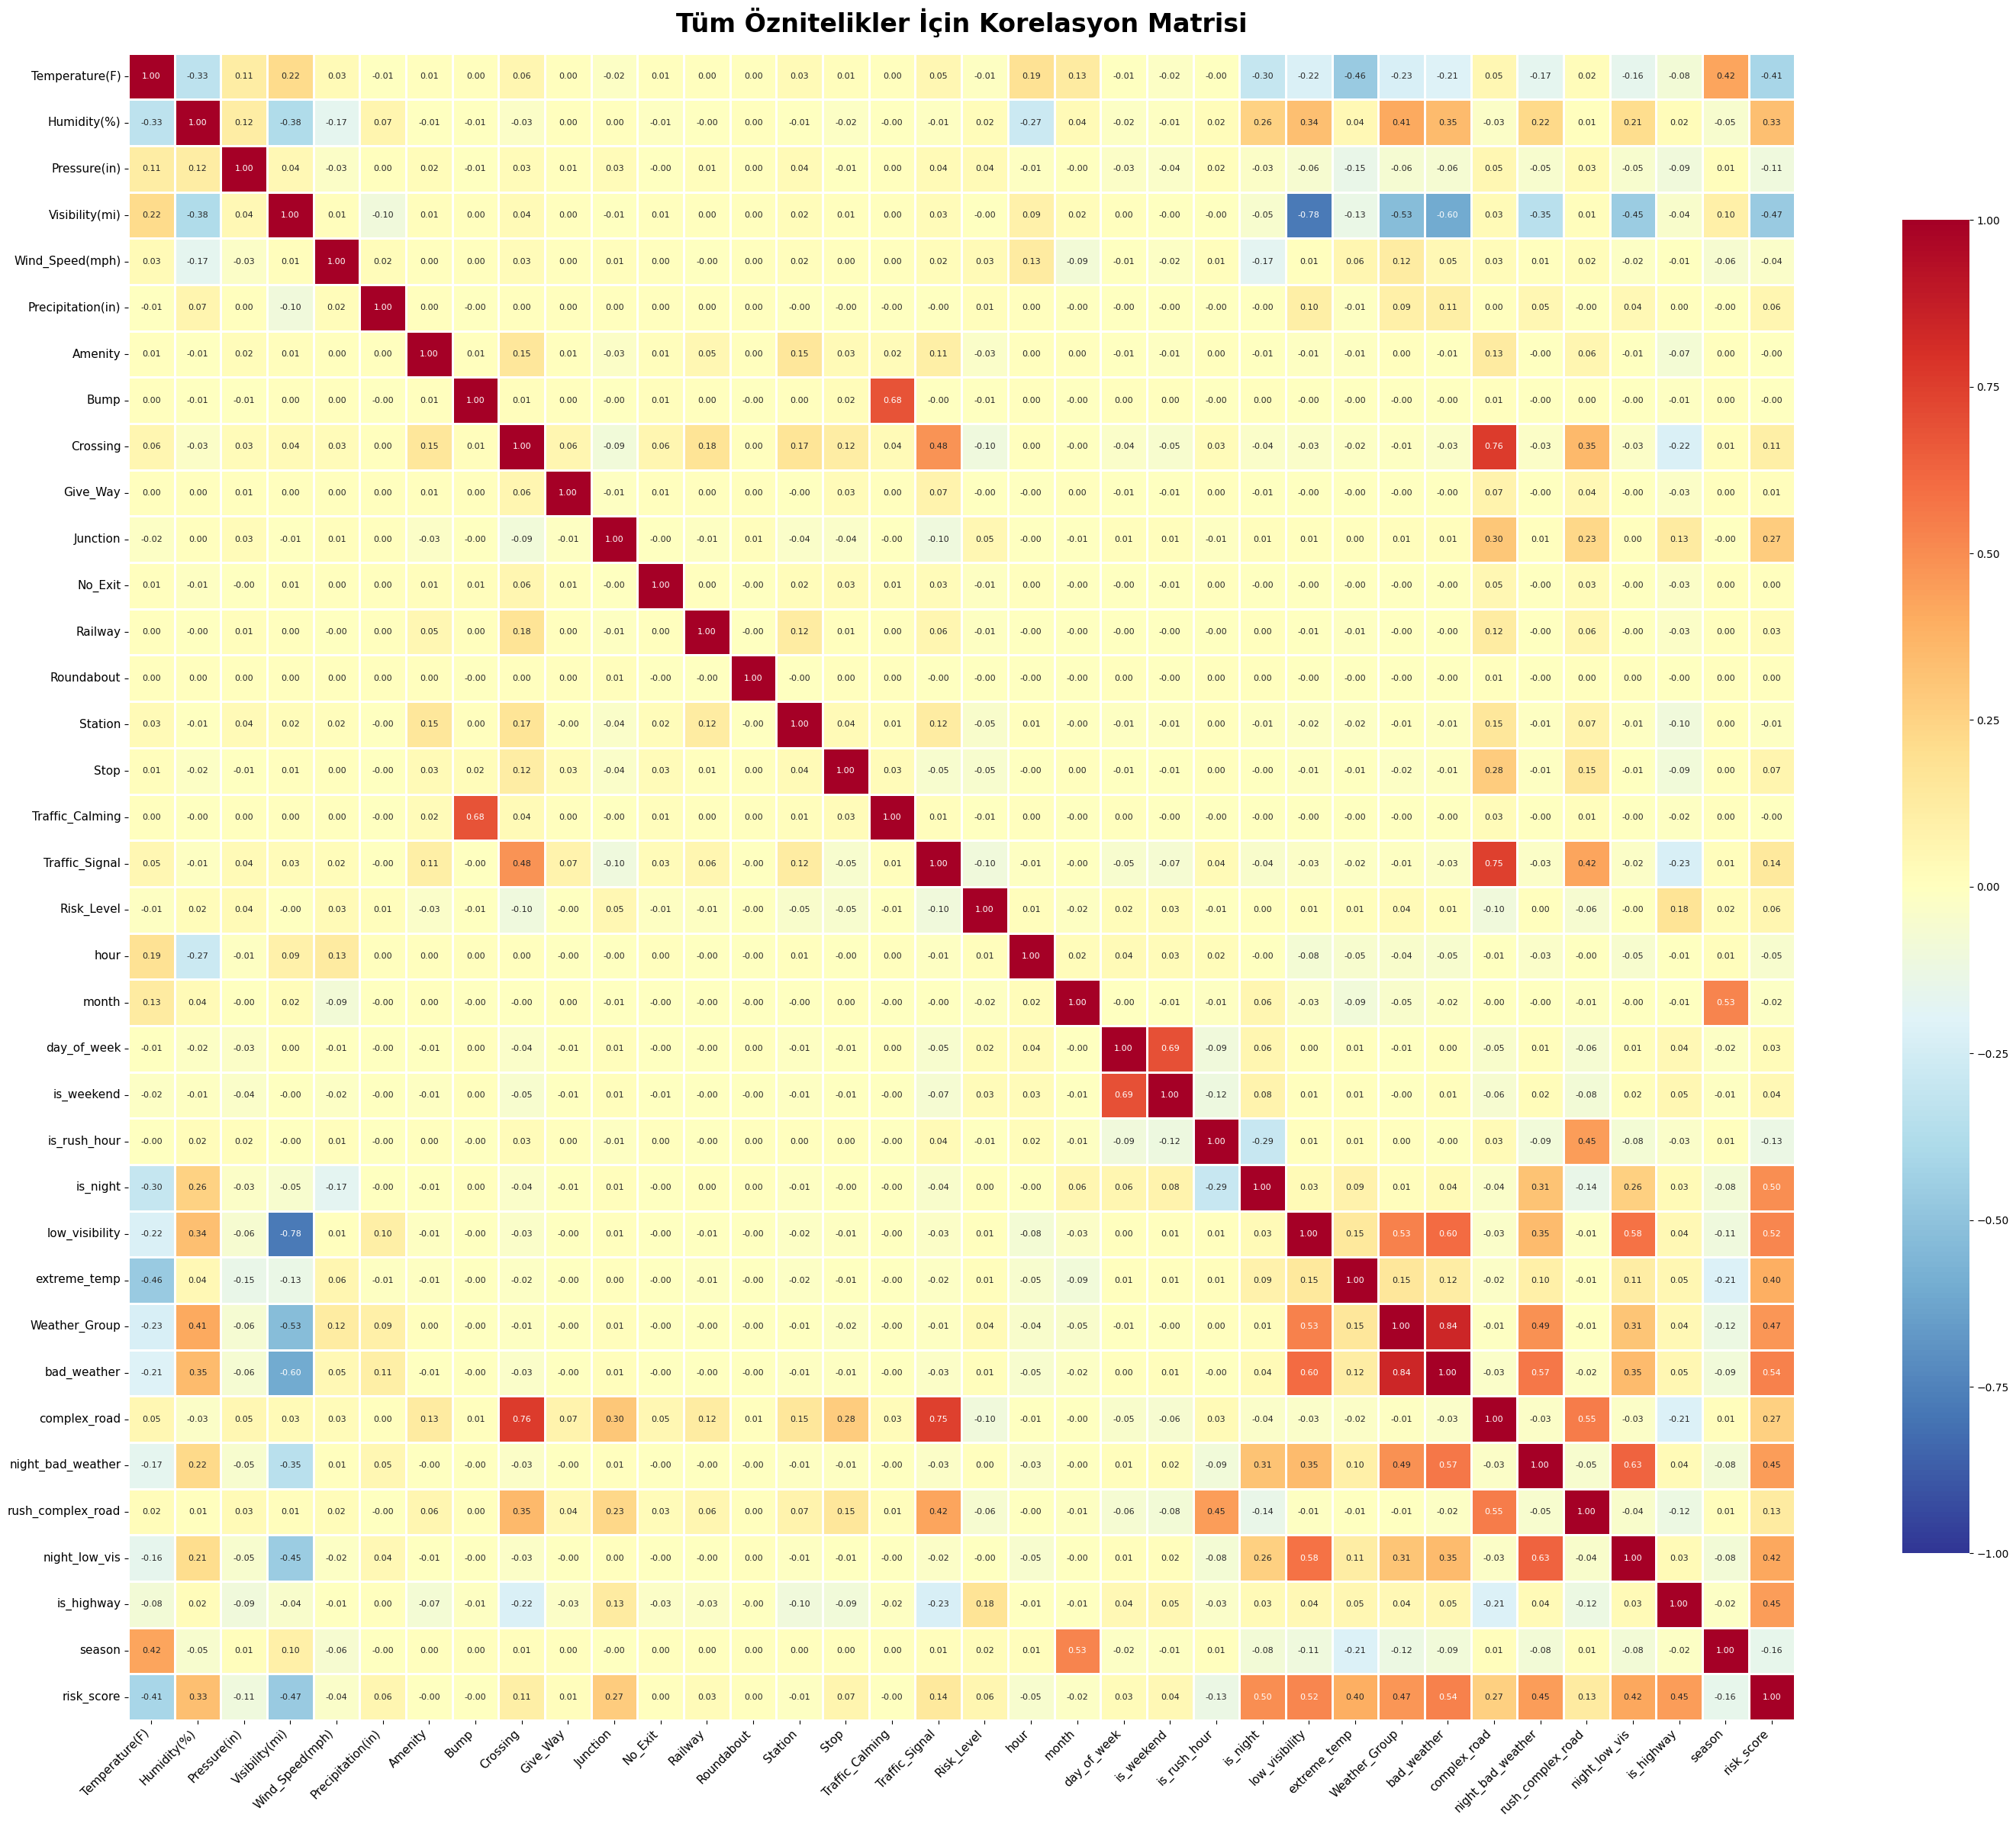

Görseldeki formatta korelasyon matrisi çizildi ve 'korelasyon_matrisi_gorsel.png' olarak kaydedildi. ✓


In [16]:
numeric_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()

# Korelasyon matrisini hesaplıyoruz
corr_matrix = df_model[numeric_cols].corr()

plt.figure(figsize=(30, 24))

cmap = "RdYlBu_r"

# korelasyon çiz
sns.heatmap(
    corr_matrix, 
    cmap=cmap, 
    vmin=-1.0, vmax=1.0, 
    annot=True,            
    fmt=".2f",             
    annot_kws={"size": 8}, 
    square=True,           
    linewidths=1.0,       
    linecolor='white',    
    cbar_kws={"shrink": 0.8} 
)

plt.title('Tüm Öznitelikler İçin Korelasyon Matrisi', fontsize=24, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.savefig('korelasyon_matrisi_gorsel.png', dpi=300, bbox_inches='tight')
plt.show()

print("Görseldeki formatta korelasyon matrisi çizildi ve 'korelasyon_matrisi_gorsel.png' olarak kaydedildi. ✓")

## HÜCRE 16 — Parquet Kaydet (Kernel düşerse tekrar yükleme)

In [17]:
df_model.to_parquet('df_model_hazir.parquet', index=False)
print('df_model kaydedildi → df_model_hazir.parquet ✓')

# Sonraki seferde direkt yükle:
# df_model = pd.read_parquet('df_model_hazir.parquet')

df_model kaydedildi → df_model_hazir.parquet ✓


## HÜCRE 17 — Train / Test Split

In [18]:
gc.collect()

feature_cols = [col for col in df_model.columns if col != 'Risk_Level']
X = df_model[feature_cols]
y = df_model['Risk_Level']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

del df_model, df, X, y
gc.collect()

print(f'Train: {X_train.shape[0]:,} satır')
print(f'Test : {X_test.shape[0]:,} satır')
print(f'Train sınıf:\n{pd.Series(y_train).value_counts()}')

Train: 6,182,715 satır
Test : 1,545,679 satır
Train sınıf:
Risk_Level
0    4979477
1    1039470
2     163768
Name: count, dtype: int64


## HÜCRE 18 — Sınıf Dengesizliği Grafiği

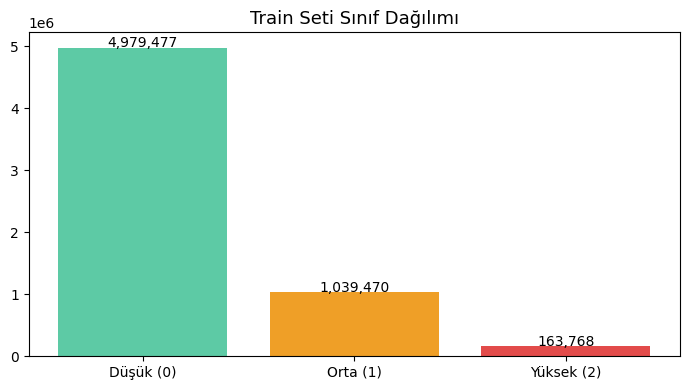

class_weight="balanced" ile yönetilecek ✓


In [19]:
fig, ax = plt.subplots(figsize=(7, 4))
counts = pd.Series(y_train).value_counts().sort_index()
ax.bar(['Düşük (0)','Orta (1)','Yüksek (2)'], counts.values,
       color=['#5DCAA5','#EF9F27','#E24B4A'])
ax.set_title('Train Seti Sınıf Dağılımı', fontsize=13)
for i, v in enumerate(counts.values):
    ax.text(i, v+5000, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()
print('class_weight="balanced" ile yönetilecek ✓')

## HÜCRE 19 — Scaling

In [20]:
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('Scaling tamamlandı ✓')

Scaling tamamlandı ✓


## HÜCRE 20 — Baseline: Yardımcı Fonksiyon

In [21]:
results = []

def evaluate_model(name, y_true, y_pred):
    acc         = accuracy_score(y_true, y_pred)
    f1_macro    = f1_score(y_true, y_pred, average='macro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    print(f"\n{'='*55}\n  {name}\n{'='*55}")
    print(f'  Accuracy    : {acc:.4f}')
    print(f'  F1 Macro    : {f1_macro:.4f}   ← asıl metrik')
    print(f'  F1 Weighted : {f1_weighted:.4f}')
    print(classification_report(y_true, y_pred, target_names=['Düşük','Orta','Yüksek']))
    return {'model':name,'accuracy':round(acc,4),
            'f1_macro':round(f1_macro,4),'f1_weighted':round(f1_weighted,4)}

print('Yardımcı fonksiyon hazır ✓')

Yardımcı fonksiyon hazır ✓


## HÜCRE 21 — Baseline 1: Dummy Classifier

In [22]:
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)
results.append(evaluate_model('Dummy (Most Frequent)', y_test, y_pred_dummy))


  Dummy (Most Frequent)
  Accuracy    : 0.8054
  F1 Macro    : 0.2974   ← asıl metrik
  F1 Weighted : 0.7186
              precision    recall  f1-score   support

       Düşük       0.81      1.00      0.89   1244870
        Orta       0.00      0.00      0.00    259867
      Yüksek       0.00      0.00      0.00     40942

    accuracy                           0.81   1545679
   macro avg       0.27      0.33      0.30   1545679
weighted avg       0.65      0.81      0.72   1545679



## HÜCRE 22 — Baseline 2: Logistic Regression (Dengesiz)

In [23]:
lr_base = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_base.fit(X_train_scaled, y_train)
y_pred_lr_base = lr_base.predict(X_test_scaled)
results.append(evaluate_model('LR — Dengesiz', y_test, y_pred_lr_base))


  LR — Dengesiz
  Accuracy    : 0.8053
  F1 Macro    : 0.2982   ← asıl metrik
  F1 Weighted : 0.7189
              precision    recall  f1-score   support

       Düşük       0.81      1.00      0.89   1244870
        Orta       0.40      0.00      0.00    259867
      Yüksek       0.00      0.00      0.00     40942

    accuracy                           0.81   1545679
   macro avg       0.40      0.33      0.30   1545679
weighted avg       0.72      0.81      0.72   1545679



## HÜCRE 23 — Baseline 3: Logistic Regression (Balanced)

In [24]:
lr_balanced = LogisticRegression(max_iter=1000, random_state=42,
                                  class_weight='balanced', n_jobs=-1)
lr_balanced.fit(X_train_scaled, y_train)
y_pred_lr_bal = lr_balanced.predict(X_test_scaled)
results.append(evaluate_model('LR — Balanced', y_test, y_pred_lr_bal))


  LR — Balanced
  Accuracy    : 0.4793
  F1 Macro    : 0.3565   ← asıl metrik
  F1 Weighted : 0.5584
              precision    recall  f1-score   support

       Düşük       0.89      0.46      0.61   1244870
        Orta       0.29      0.57      0.39    259867
      Yüksek       0.04      0.38      0.07     40942

    accuracy                           0.48   1545679
   macro avg       0.41      0.47      0.36   1545679
weighted avg       0.77      0.48      0.56   1545679



## HÜCRE 24 — Baseline Karşılaştırma & Confusion Matrix


BASELINE KARŞILAŞTIRMA TABLOSU
                       accuracy  f1_macro  f1_weighted
model                                                 
Dummy (Most Frequent)      0.81      0.30         0.72
LR — Dengesiz              0.81      0.30         0.72
LR — Balanced              0.48      0.36         0.56

→ En iyi: LR — Balanced (0.3565)


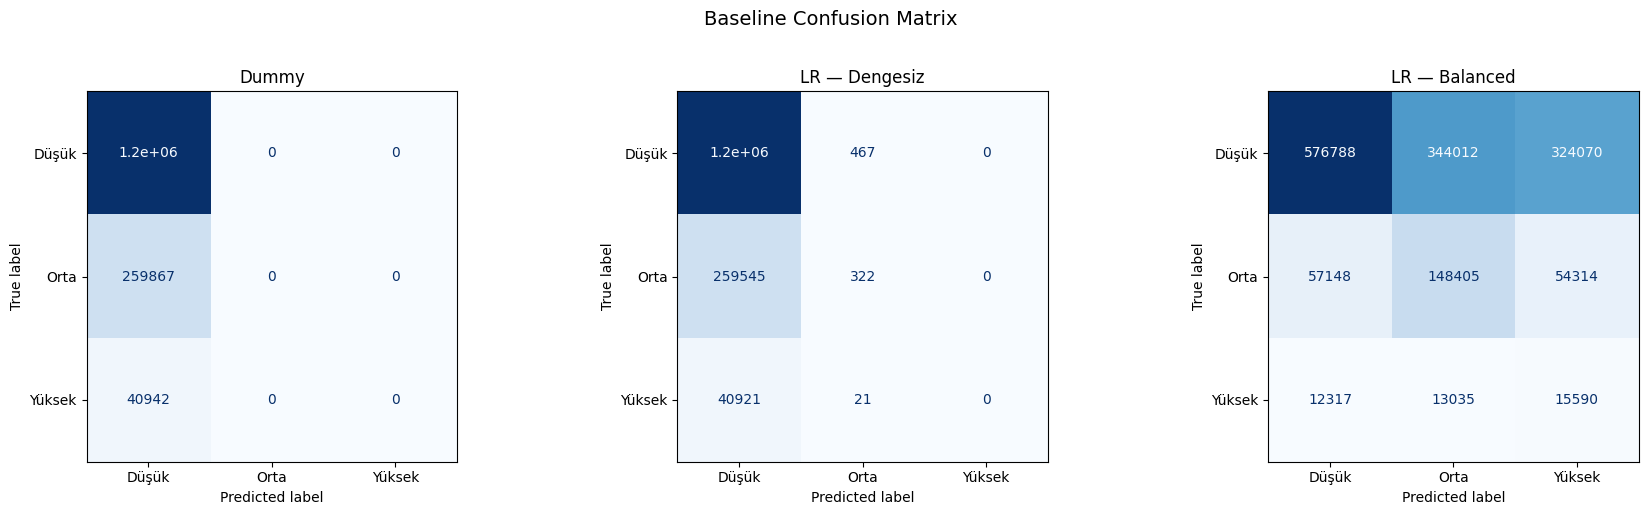

In [25]:
df_results = pd.DataFrame(results).set_index('model')
print('\nBASELINE KARŞILAŞTIRMA TABLOSU')
print(df_results.to_string())

best = df_results['f1_macro'].idxmax()
print(f'\n→ En iyi: {best} ({df_results.loc[best,"f1_macro"]:.4f})')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (y_pred, title) in zip(axes, [
    (y_pred_dummy,   'Dummy'),
    (y_pred_lr_base, 'LR — Dengesiz'),
    (y_pred_lr_bal,  'LR — Balanced'),
]):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Düşük','Orta','Yüksek']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=12)
plt.suptitle('Baseline Confusion Matrix', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('baseline_cm.png', dpi=150, bbox_inches='tight')
plt.show()

## HÜCRE 25 — LazyPredict (50K örneklem)

In [26]:
X_sample, y_sample = resample(
    X_train_scaled, y_train, n_samples=50_000, random_state=42, stratify=y_train
)
X_test_sample, y_test_sample = resample(
    X_test_scaled, y_test, n_samples=10_000, random_state=42, stratify=y_test
)

clf = LazyClassifier(verbose=0, ignore_warnings=True)
models, predictions = clf.fit(X_sample, X_test_sample, y_sample, y_test_sample)
print(models.sort_values('F1 Score', ascending=False).head(10))

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004372 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 794
[LightGBM] [Info] Number of data points in the train set: 50000, number of used features: 34
[LightGBM] [Info] Start training from score -0.216441
[LightGBM] [Info] Start training from score -1.783077
[LightGBM] [Info] Start training from score -3.630611
                            Accuracy  Balanced Accuracy ROC AUC  F1 Score  \
Model                                                                       
XGBClassifier                   0.81               0.38    None      0.76   
LGBMClassifier                  0.81               0.37    None      0.76   
BaggingClassifier               0.80               0.38    None      0.75   
RandomForestClassifier          0.81               0.36    None      0.75   
KNeighborsClassifier    

## HÜCRE 26 — Model Karşılaştırma (LightGBM Dengesiz vs Balanced)

In [27]:
modeller = {
    'LightGBM_Dengesiz': LGBMClassifier(n_estimators=100, random_state=42, n_jobs=2, verbose=-1),
    'LightGBM_Balanced': LGBMClassifier(n_estimators=100, random_state=42, n_jobs=2,
                                        class_weight='balanced', verbose=-1)
}
tum_sonuclar = []

for isim, model in modeller.items():
    print(f'\n[{isim}] eğitiliyor...')
    start = time.time()
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    sure = time.time() - start
    tum_sonuclar.append({
        'Model': isim,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'F1-Macro': round(f1_score(y_test, y_pred, average='macro'), 4),
        'F1-Weighted': round(f1_score(y_test, y_pred, average='weighted'), 4),
        'Sure (sn)': round(sure, 2)
    })
    print(classification_report(y_test, y_pred, target_names=['Düşük','Orta','Yüksek']))

df_mod = pd.DataFrame(tum_sonuclar).sort_values('F1-Macro', ascending=False)
print('\n SONUÇ TABLOSU')
print(df_mod.to_string(index=False))


[LightGBM_Dengesiz] eğitiliyor...
              precision    recall  f1-score   support

       Düşük       0.83      0.97      0.90   1244870
        Orta       0.57      0.20      0.30    259867
      Yüksek       0.78      0.00      0.00     40942

    accuracy                           0.82   1545679
   macro avg       0.73      0.39      0.40   1545679
weighted avg       0.79      0.82      0.77   1545679


[LightGBM_Balanced] eğitiliyor...
              precision    recall  f1-score   support

       Düşük       0.92      0.52      0.67   1244870
        Orta       0.33      0.63      0.43    259867
      Yüksek       0.05      0.44      0.09     40942

    accuracy                           0.54   1545679
   macro avg       0.43      0.53      0.40   1545679
weighted avg       0.79      0.54      0.61   1545679


 SONUÇ TABLOSU
            Model  Accuracy  F1-Macro  F1-Weighted  Sure (sn)
LightGBM_Dengesiz      0.82      0.40         0.77     147.41
LightGBM_Balanced      0.54 

## HÜCRE 27 — Optuna: Hiperparametre Optimizasyonu (F2 Macro)

In [28]:
def objective(trial):
    param = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 200, step=50),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.05, 0.2, log=True),
        'num_leaves'       : trial.suggest_int('num_leaves', 30, 150),
        'min_child_samples': trial.suggest_int('min_child_samples', 100, 500),
        'class_weight': 'balanced', 'random_state': 42, 'n_jobs': 2, 'verbose': -1
    }
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    f2_skorlari = []
    for train_idx, val_idx in skf.split(X_train_scaled, y_train):
        X_tr, X_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
        y_tr, y_val = y_train.iloc[train_idx],   y_train.iloc[val_idx]
        # 200K örneklem — hız için
        idx = np.random.choice(len(X_tr), size=200_000, replace=False)
        model = LGBMClassifier(**param)
        model.fit(X_tr[idx], y_tr.iloc[idx])
        y_pred_val = model.predict(X_val)
        f2_skorlari.append(fbeta_score(y_val, y_pred_val, beta=2, average='macro'))
    return np.mean(f2_skorlari)

print('Optuna başlıyor — F2 Macro hedef...')
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=8)

print(f'\nEn iyi F2 Macro : {study.best_value:.4f}')
print(f'En iyi parametreler: {study.best_params}')

Optuna başlıyor — F2 Macro hedef...

En iyi F2 Macro : 0.4562
En iyi parametreler: {'n_estimators': 100, 'learning_rate': 0.15245880828809955, 'num_leaves': 149, 'min_child_samples': 316}


## HÜCRE 28 — Final Model Eğitimi

In [29]:
# Optuna'nın bulduğu parametreler — study.best_params veya manuel gir
best_params = {
    **study.best_params,
    'class_weight'     : 'balanced',
    'random_state'     : 42,
    'n_jobs'           : 2,
    'verbose'          : -1
}

print('Final model eğitiliyor...')
final_model = LGBMClassifier(**best_params)
final_model.fit(X_train_scaled, y_train)

y_pred_direkt = final_model.predict(X_test_scaled)
print(f'\nEşiksiz F1 Macro: {f1_score(y_test, y_pred_direkt, average="macro"):.4f}')
print(classification_report(y_test, y_pred_direkt, target_names=['Düşük','Orta','Yüksek']))

Final model eğitiliyor...

Eşiksiz F1 Macro: 0.4098
              precision    recall  f1-score   support

       Düşük       0.92      0.54      0.68   1244870
        Orta       0.34      0.64      0.44    259867
      Yüksek       0.06      0.46      0.11     40942

    accuracy                           0.56   1545679
   macro avg       0.44      0.55      0.41   1545679
weighted avg       0.80      0.56      0.63   1545679



## HÜCRE 29 — Cross Validation Skoru (Final Model)

In [30]:
print('Cross-validation başlıyor (3-Fold, F1 Macro)...')
print('(3-5 dakika sürebilir)\n')

# CV için örneklem — 7.7M satırda çok yavaş olur
from sklearn.utils import resample
X_cv, y_cv = resample(
    X_train_scaled, y_train,
    n_samples=200_000,
    random_state=42,
    stratify=y_train
)

cv_model = LGBMClassifier(**best_params)
cv_scores = cross_val_score(
    cv_model, X_cv, y_cv,
    cv=3,
    scoring='f1_macro',
    n_jobs=2
)

print('=' * 50)
print('CROSS VALIDATION SONUÇLARI')
print('=' * 50)
print(f'Fold skorları : {[round(s,4) for s in cv_scores]}')
print(f'Ortalama F1  : {cv_scores.mean():.4f}')
print(f'Std sapma    : {cv_scores.std():.4f}')
print(f'\n→ Model kararlılığı: {"İyi ✓" if cv_scores.std() < 0.01 else "Kontrol et ⚠"}')

Cross-validation başlıyor (3-Fold, F1 Macro)...
(3-5 dakika sürebilir)

CROSS VALIDATION SONUÇLARI
Fold skorları : [np.float64(0.4325), np.float64(0.43), np.float64(0.4341)]
Ortalama F1  : 0.4322
Std sapma    : 0.0017

→ Model kararlılığı: İyi ✓


## HÜCRE 30 — Eşik Analizi (Threshold)

In [31]:
y_probs = final_model.predict_proba(X_test_scaled)
esikler = np.arange(0.25, 0.66, 0.05)
esik_sonuclari = []

for esik in esikler:
    y_pred_esik = np.array([
        2 if y_probs[i,2] >= esik else np.argmax(y_probs[i,:2])
        for i in range(len(y_probs))
    ])
    rapor  = classification_report(y_test, y_pred_esik, output_dict=True)
    esik_sonuclari.append({
        'Esik'            : f'{esik:.0%}',
        'Accuracy'        : round(accuracy_score(y_test, y_pred_esik), 4),
        'F1 Macro'        : round(f1_score(y_test, y_pred_esik, average='macro'), 4),
        'F2 Macro'        : round(fbeta_score(y_test, y_pred_esik, beta=2, average='macro'), 4),
        'Yüksek Recall'   : round(rapor['2']['recall'], 4),
        'Yüksek Precision': round(rapor['2']['precision'], 4),
    })

df_esik = pd.DataFrame(esik_sonuclari)
print(df_esik.to_string(index=False))

en_iyi_esik = 0.45
idx = np.argmin(np.abs(esikler - en_iyi_esik))
satir = df_esik.iloc[idx]

print(f'\n→ En iyi eşik  : {en_iyi_esik:.0%}')
print(f'→ Gerçek eşik  : {satir["Esik"]}')
print(f'→ F2 Macro     : {satir["F2 Macro"]:.4f}')
print(f'→ Yüksek Recall: {satir["Yüksek Recall"]:.4f}')

Esik  Accuracy  F1 Macro  F2 Macro  Yüksek Recall  Yüksek Precision
 25%      0.32      0.29      0.29           0.82              0.04
 30%      0.41      0.34      0.35           0.70              0.04
 35%      0.49      0.38      0.40           0.58              0.05
 40%      0.55      0.41      0.44           0.46              0.06
 45%      0.59      0.42      0.46           0.36              0.07
 50%      0.63      0.44      0.47           0.27              0.08
 55%      0.65      0.45      0.48           0.20              0.10
 60%      0.66      0.45      0.47           0.14              0.12
 65%      0.67      0.45      0.47           0.10              0.15

→ En iyi eşik  : 45%
→ Gerçek eşik  : 45%
→ F2 Macro     : 0.4619
→ Yüksek Recall: 0.3556


## HÜCRE 31 — Final Tahmin & Confusion Matrix

NİHAİ SONUÇ — Eşik: 45%
              precision    recall  f1-score   support

       Düşük       0.91      0.58      0.71   1244870
        Orta       0.33      0.68      0.44    259867
      Yüksek       0.07      0.36      0.12     40942

    accuracy                           0.59   1545679
   macro avg       0.44      0.54      0.42   1545679
weighted avg       0.79      0.59      0.65   1545679



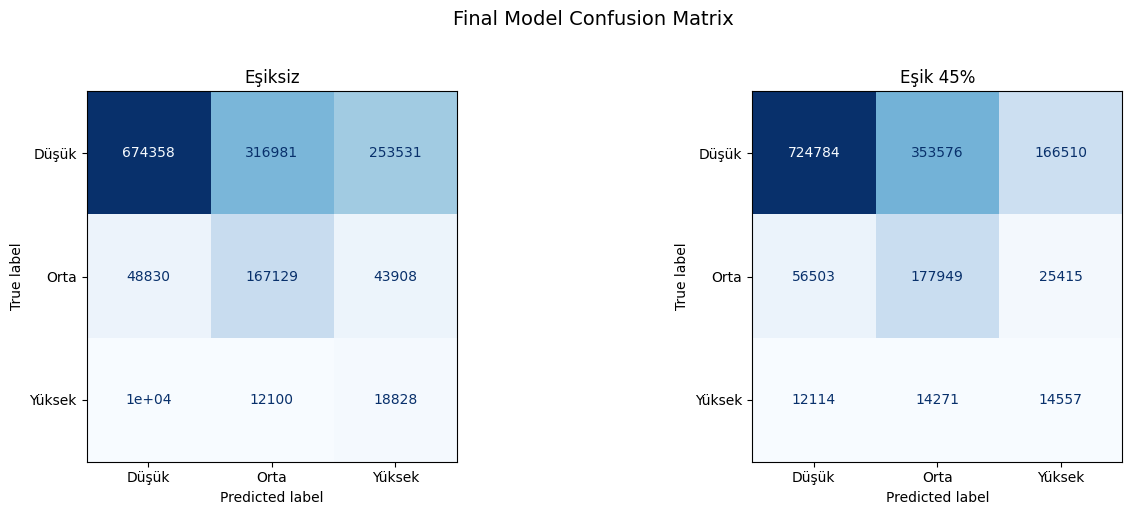

Grafik kaydedildi → final_cm.png


In [32]:
y_pred_final = np.array([
    2 if y_probs[i,2] >= en_iyi_esik else np.argmax(y_probs[i,:2])
    for i in range(len(y_probs))
])

print(f'NİHAİ SONUÇ — Eşik: {en_iyi_esik:.0%}')
print(classification_report(y_test, y_pred_final, target_names=['Düşük','Orta','Yüksek']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (y_p, title) in zip(axes, [
    (y_pred_direkt, 'Eşiksiz'),
    (y_pred_final,  f'Eşik {en_iyi_esik:.0%}'),
]):
    cm = confusion_matrix(y_test, y_p)
    ConfusionMatrixDisplay(cm, display_labels=['Düşük','Orta','Yüksek']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=12)
plt.suptitle('Final Model Confusion Matrix', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('final_cm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik kaydedildi → final_cm.png')

## HÜCRE 32 — Final Model Değerlendirmesi

Model değerlendirme grafikleri hazırlanıyor...


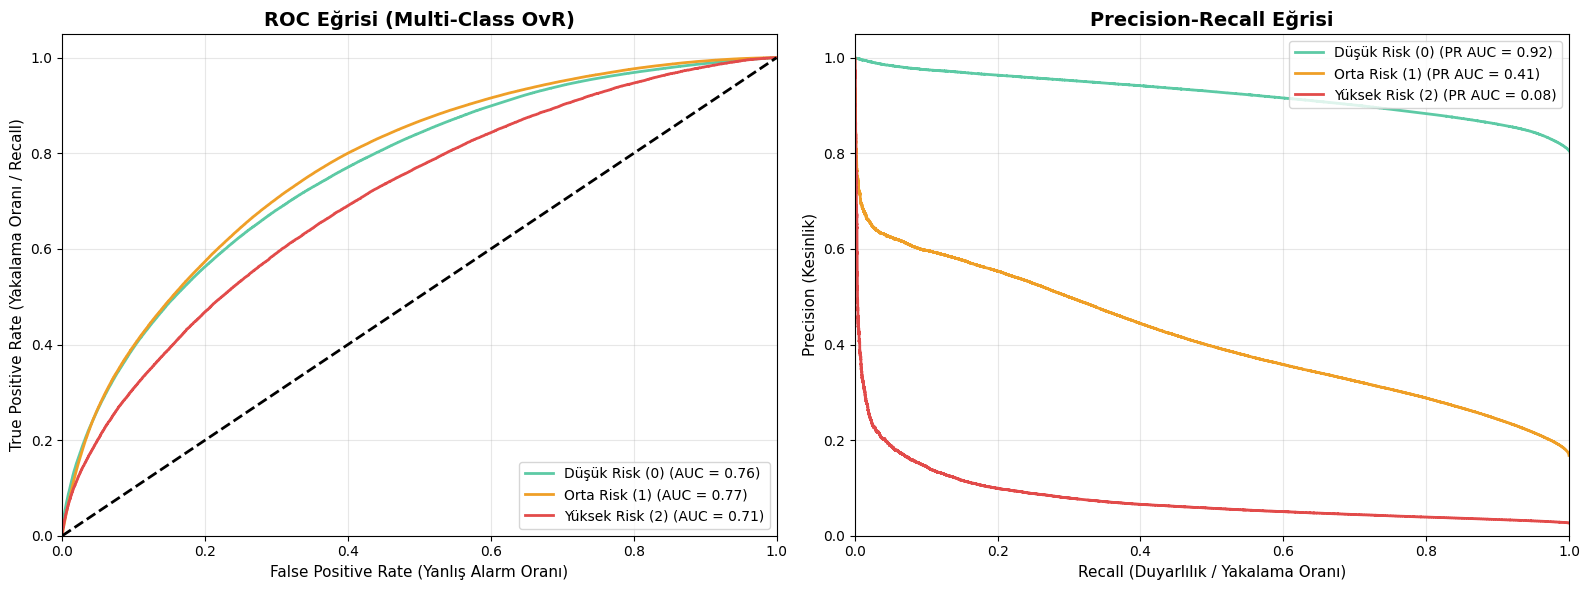

Grafikler kaydedildi → roc_pr_evaluation.png ✓


In [33]:
print("Model değerlendirme grafikleri hazırlanıyor...")

# Sınıfları binarize etmek
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
renkler = ['#5DCAA5', '#EF9F27', '#E24B4A']
etiketler = ['Düşük Risk (0)', 'Orta Risk (1)', 'Yüksek Risk (2)']

# 1. GRAFİK: ROC Eğrisi ve AUC (Alan)
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=renkler[i], lw=2, 
                 label=f'{etiketler[i]} (AUC = {roc_auc:.2f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=2)
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate (Yanlış Alarm Oranı)', fontsize=11)
axes[0].set_ylabel('True Positive Rate (Yakalama Oranı / Recall)', fontsize=11)
axes[0].set_title('ROC Eğrisi (Multi-Class OvR)', fontsize=14, fontweight='bold')
axes[0].legend(loc="lower right", fontsize=10)
axes[0].grid(alpha=0.3)

# 2. GRAFİK: Precision-Recall Eğrisi ve PR AUC
for i in range(3):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_probs[:, i])
    pr_auc = average_precision_score(y_test_bin[:, i], y_probs[:, i])
    axes[1].plot(recall, precision, color=renkler[i], lw=2, 
                 label=f'{etiketler[i]} (PR AUC = {pr_auc:.2f})')

axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall (Duyarlılık / Yakalama Oranı)', fontsize=11)
axes[1].set_ylabel('Precision (Kesinlik)', fontsize=11)
axes[1].set_title('Precision-Recall Eğrisi', fontsize=14, fontweight='bold')
axes[1].legend(loc="upper right", fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_pr_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print("Grafikler kaydedildi → roc_pr_evaluation.png ✓")

## Hücre 32.5 — Koruma Uygulamanın Kaldığı Yerden Devam Etmesi

In [34]:
print("Kaydedilmiş model ve veriler hafızaya alınıyor...")

# 1. Modeli ve Scaler'ı bilgisayardan geri yükle (40 dk beklemeye son!)
final_model = joblib.load('trafik_risk_modeli.joblib')
scaler = joblib.load('trafik_scaler.joblib')

# 2. X_test_scaled verisine SHAP analizi için ihtiyacımız var. 
# Sadece veri setini okuyup Test setini tekrar oluşturmamız 5 saniye sürer.
# Parquet dosyasından hızlıca okuyalım:
df_model = pd.read_parquet('df_model_hazir.parquet')

feature_cols = [col for col in df_model.columns if col != 'Risk_Level']
X = df_model[feature_cols]
y = df_model['Risk_Level']

# Aynı random_state=42 ile böldüğümüz için X_test tamamen aynı satırlar olacaktır.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaler'ı yeniden "fit" etmiyoruz! Sadece kaydettiğimiz scaler ile transform ediyoruz.
X_test_scaled = scaler.transform(X_test)

print("Her şey hazır! Kaldığın yerden (Hücre 32 - SHAP) devam edebilirsin.")

Kaydedilmiş model ve veriler hafızaya alınıyor...
Her şey hazır! Kaldığın yerden (Hücre 32 - SHAP) devam edebilirsin.


## HÜCRE 33 — Açıklanabilir Yapay Zeka Ve Risk Skoru

SHAP analizi için hazırlık yapılıyor...
(Ağaç yapısı inceleneceği için 1-2 dakika sürebilir)

 YÜKSEK RİSK (AĞIR KAZALAR) İÇİN SHAP ÖZELLİK ETKİSİ 


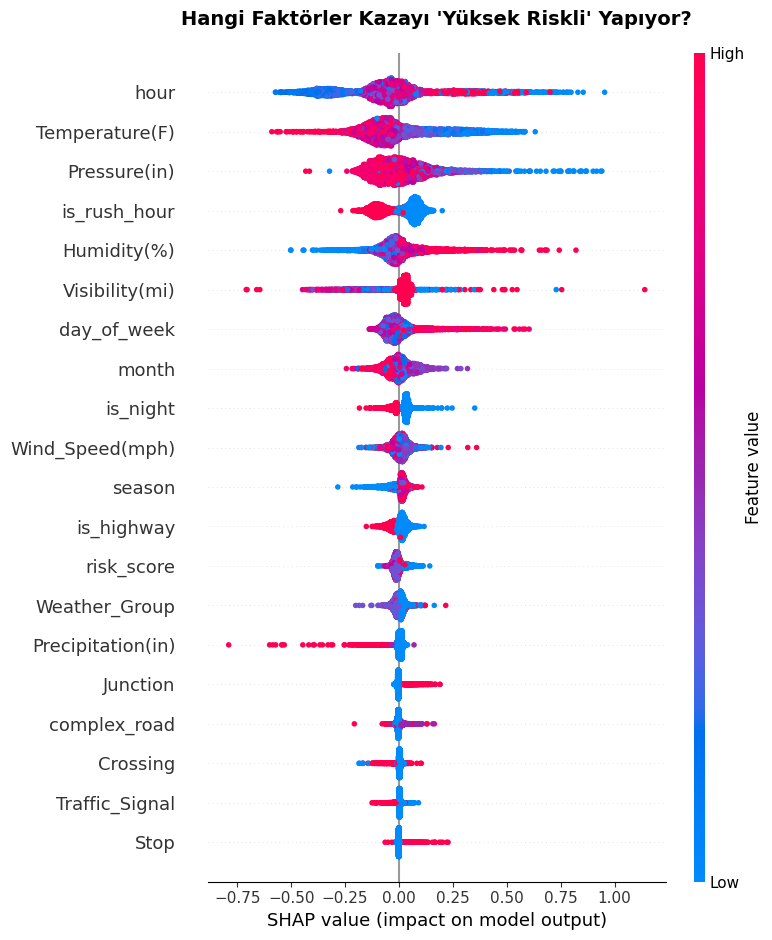

Grafik kaydedildi → shap_summary_yuksek_risk.png ✓


In [35]:
print("SHAP analizi için hazırlık yapılıyor...")
print("(Ağaç yapısı inceleneceği için 1-2 dakika sürebilir)")

# Bütün test setini kullanmak belleği doldurabilir bu durumda test setinden 5k lık örneklem alıyoruz
np.random.seed(42)
sample_indices = np.random.choice(X_test_scaled.shape[0], size=5000, replace=False)
X_test_sample = X_test_scaled[sample_indices]

feature_names = list(X_train.columns) if hasattr(X_train, "columns") else [f"feature_{i}" for i in range(X_test_scaled.shape[1])]

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_sample)

print("\n" + "="*60)
print(" YÜKSEK RİSK (AĞIR KAZALAR) İÇİN SHAP ÖZELLİK ETKİSİ ")
print("="*60)

if isinstance(shap_values, list):
    shap_values_yuksek_risk = shap_values[2]
else:
    shap_values_yuksek_risk = shap_values[:, :, 2]

plt.figure(figsize=(12, 8))
# Sadece Yüksek Risk (index 2) kararlarını etkileyen faktörleri çizdiriyoruz
shap.summary_plot(shap_values_yuksek_risk, X_test_sample, feature_names=feature_names, show=False)
plt.title("Hangi Faktörler Kazayı 'Yüksek Riskli' Yapıyor?", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('shap_summary_yuksek_risk.png', dpi=150, bbox_inches='tight')
plt.show()

print("Grafik kaydedildi → shap_summary_yuksek_risk.png ✓")

## HÜCRE 34 — Modeli Dışa Aktarma

In [36]:
print("Model ve dönüştürücüler kaydediliyor...")

# Modeli kaydetmek
joblib.dump(final_model, 'trafik_risk_modeli.joblib')

# Testi ölçekleme
joblib.dump(scaler, 'trafik_scaler.joblib')

print("Kayıt işlemi başarılı! (.joblib dosyaları proje klasörüne eklendi) ✓")

Model ve dönüştürücüler kaydediliyor...
Kayıt işlemi başarılı! (.joblib dosyaları proje klasörüne eklendi) ✓
